ipynb version of test.py file

In [1]:
import os
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

device = "cpu"

In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
if (cwd / "data" / "train").exists():
    BASE_DIR = cwd
elif (cwd.parent / "data" / "train").exists():
    BASE_DIR = cwd.parent
else:
    raise FileNotFoundError("Could not locate repo root containing data/train")

TRAIN_ROOT = BASE_DIR / "data" / "train"

SIM_DIRS = [
    TRAIN_ROOT / "pair_1_grid_2D",
    TRAIN_ROOT / "pair_2_grid_2D",
]

for d in SIM_DIRS:
    assert d.is_dir(), f"Missing directory: {d}"


def split_simulation_frames(sim_dir, train_frac=0.8):
    files = sorted(
        glob.glob(str(sim_dir / "frame_*_grid.npz")),
        key=lambda f: int(Path(f).stem.split("_")[1])
    )

    n_total = len(files)
    n_train = int(train_frac * n_total)

    train_files = files[:n_train]
    test_files  = files[n_train:]

    return train_files, test_files


train_files = []
test_files  = []

for sim_dir in SIM_DIRS:
    tr, te = split_simulation_frames(sim_dir, train_frac=0.8)
    train_files.extend(tr)
    test_files.extend(te)

print("===================================")
print(f"Simulations used   : {len(SIM_DIRS)}")
print(f"Train samples     : {len(train_files)}")
print(f"Test samples      : {len(test_files)}")
print("===================================")

assert len(train_files) > 0
assert len(test_files) > 0


Simulations used   : 2
Train samples     : 44
Test samples      : 12


In [3]:
class VPMGridDataset(Dataset):
    """
    Operator dataset:
        a(x,y) -> u(x,y)

    input_grid : (3, Nx, Ny)   [ω, σ, vol]
    U_grid     : (2, Nx, Ny)   [u_x, u_y]
    """

    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])

        x = torch.tensor(data["input_grid"], dtype=torch.float32)
        y = torch.tensor(data["U_grid"], dtype=torch.float32)

        return {"x": x, "y": y}


train_dataset = VPMGridDataset(train_files)
test_dataset  = VPMGridDataset(test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

test_loaders = {32: test_loader}

In [4]:
model = FNO(
    n_modes=(20, 20),
    in_channels=3,
    out_channels=2,
    hidden_channels=64,
    projection_channel_ratio=4,
).to(device)

print(model)
print("Total parameters:", count_model_params(model))


optimizer = AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=120
)

l2loss = LpLoss(d=2, p=2)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 20, 11]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 2, kernel_s

In [5]:
trainer = Trainer(
    model=model,
    n_epochs=120,
    device=device,
    data_processor=None,
    wandb_log=False,
    eval_interval=5,
    verbose=True,
)

trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    training_loss=l2loss,
    eval_losses={"l2": l2loss},
)

Training on 44 samples
Testing on [12] samples         on resolutions [32].
Raw outputs of shape torch.Size([2, 2, 32, 32])


/home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/neuralop-env/lib/python3.10/site-packages/torch/nn/modules/module.py:1786: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/neuralop-env/lib/python3.10/site-packages/neuralop/training/trainer.py:536: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=3.39, avg_loss=35.9090, train_err=71.8180
Eval: 32_l2=25.4838
[5] time=3.32, avg_loss=3.4042, train_err=6.8084
Eval: 32_l2=5.4341
[10] time=2.36, avg_loss=1.3652, train_err=2.7303
Eval: 32_l2=1.5244
[15] time=2.48, avg_loss=1.1873, train_err=2.3746
Eval: 32_l2=1.0630
[20] time=2.68, avg_loss=1.4954, train_err=2.9908
Eval: 32_l2=1.2371
[25] time=2.56, avg_loss=1.3603, train_err=2.7206
Eval: 32_l2=1.0495
[30] time=2.44, avg_loss=0.9499, train_err=1.8998
Eval: 32_l2=0.9847
[35] time=2.54, avg_loss=0.5978, train_err=1.1956
Eval: 32_l2=0.7308
[40] time=2.60, avg_loss=0.6538, train_err=1.3075
Eval: 32_l2=0.5646
[45] time=2.17, avg_loss=0.3539, train_err=0.7078
Eval: 32_l2=0.4128
[50] time=2.06, avg_loss=0.4233, train_err=0.8466
Eval: 32_l2=0.4064
[55] time=2.46, avg_loss=0.6735, train_err=1.3470
Eval: 32_l2=0.4799
[60] time=2.57, avg_loss=0.5641, train_err=1.1283
Eval: 32_l2=0.6003
[65] time=1.91, avg_loss=0.5039, train_err=1.0079
Eval: 32_l2=0.4700
[70] time=2.05, avg_loss=0.2485, 

{'train_err': 0.14957446181638676,
 'avg_loss': 0.07478723090819338,
 'avg_lasso_loss': None,
 'epoch_train_time': 2.4345581629895605}

In [8]:
model.eval()

sample = test_dataset[0]
x = sample["x"].unsqueeze(0).to(device)
y_true = sample["y"]

with torch.no_grad():
    y_pred = model(x)[0].cpu()

speed_true = torch.sqrt(y_true[0]**2 + y_true[1]**2)
speed_pred = torch.sqrt(y_pred[0]**2 + y_pred[1]**2)
error = torch.norm(y_pred - y_true, dim=0)

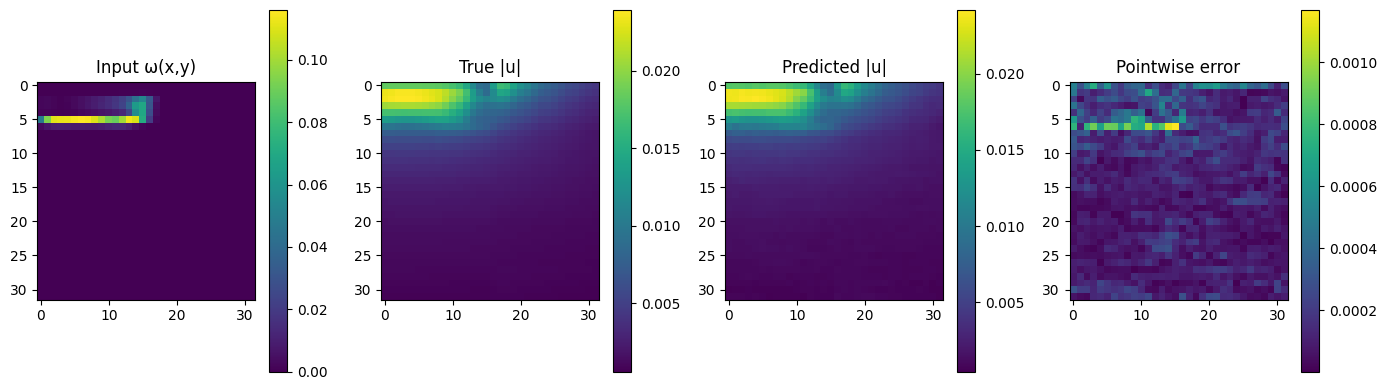

In [9]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(x[0, 0].cpu())
plt.title("Input ω(x,y)")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.imshow(speed_true)
plt.title("True |u|")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.imshow(speed_pred)
plt.title("Predicted |u|")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(error)
plt.title("Pointwise error")
plt.colorbar()

plt.tight_layout()
plt.show()